In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/ML/US_Accidents_March23.csv"

df = pd.read_csv(path, nrows=100000)

df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [ ]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     100000 non-null  object 
 1   Source                 100000 non-null  object 
 2   Severity               100000 non-null  int64  
 3   Start_Time             100000 non-null  object 
 4   End_Time               100000 non-null  object 
 5   Start_Lat              100000 non-null  float64
 6   Start_Lng              100000 non-null  float64
 7   End_Lat                0 non-null       float64
 8   End_Lng                0 non-null       float64
 9   Distance(mi)           100000 non-null  float64
 10  Description            100000 non-null  object 
 11  Street                 100000 non-null  object 
 12  City                   99999 non-null   object 
 13  County                 100000 non-null  object 
 14  State                  100000 non-nul

In [ ]:
df = df[['Severity',
         'Temperature(F)',
         'Humidity(%)',
         'Pressure(in)',
         'Visibility(mi)',
         'Wind_Speed(mph)',
         'Weather_Condition',
         'Start_Lat',
         'Start_Lng']]

In [ ]:
df.head()

,Severity,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Weather_Condition,Start_Lat,Start_Lng
0,3,36.9,91.0,29.68,10.0,NaN,Light Rain,39.865147,-84.058723
1,2,37.9,100.0,29.65,10.0,NaN,Light Rain,39.928059,-82.831184
2,2,36.0,100.0,29.67,10.0,3.5,Overcast,39.063148,-84.032608
3,3,35.1,96.0,29.64,9.0,4.6,Mostly Cloudy,39.747753,-84.205582
4,2,36.0,89.0,29.65,6.0,3.5,Mostly Cloudy,39.627781,-84.188354


In [ ]:
df = pd.read_csv(path, chunksize=100000)

df = next(df)

In [ ]:
# numerical summary
df.describe()

# categorical summary
df.describe(include='object')

,ID,Source,Start_Time,End_Time,Description,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Weather_Timestamp,Wind_Direction,Weather_Condition,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
count,100000,100000,100000,100000,100000,100000,99999,100000,100000,99993,100000,99993,99993,98946,98936,98396,99999,99999,99999,99999
unique,100000,2,98896,96724,71519,9119,785,71,3,12001,1,2,121,37246,24,43,2,2,2,2
top,A-99990,Source2,2016-04-10 08:59:26,2016-10-14 19:50:00,Accident on I-80 Westbound at Exits 8A 8B I-880.,I-5 N,Los Angeles,Los Angeles,CA,91706,US,US/Pacific,KCQT,2016-11-03 10:53:00,Calm,Clear,Day,Day,Day,Day
freq,1,99950,35,24,55,2921,9792,33466,99272,712,100000,99265,7372,37,21920,57255,62510,66178,70266,74325


In [ ]:
# total missing values
df.isnull().sum()

# percentage of missing values
(df.isnull().mean())*100

,0
ID,0.000
Source,0.000
Severity,0.000
Start_Time,0.000
End_Time,0.000
Start_Lat,0.000
Start_Lng,0.000
End_Lat,100.000
End_Lng,100.000
Distance(mi),0.000


In [ ]:
# check duplicates
df.duplicated().sum()

# remove duplicates
df.drop_duplicates(inplace=True)

# check shape again
print(df.shape)

(100000, 46)


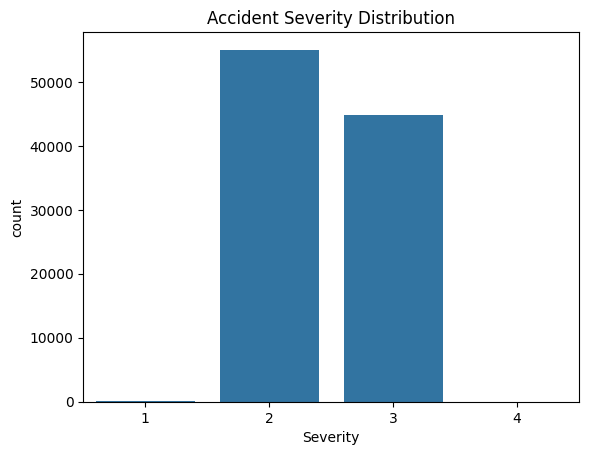

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Severity', data=df)
plt.title("Accident Severity Distribution")
plt.show()

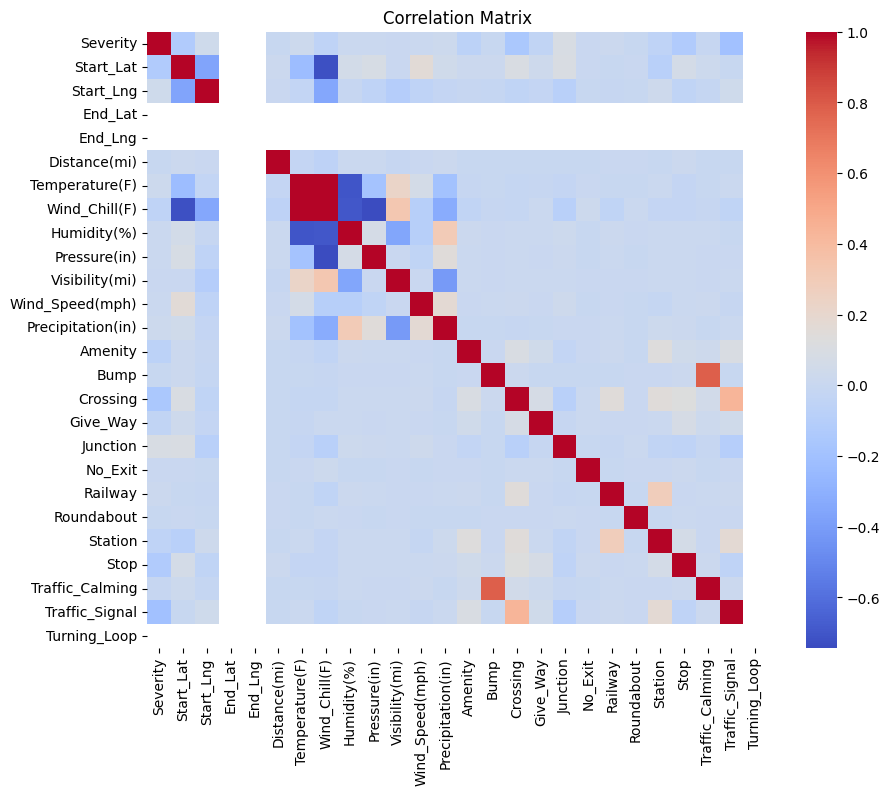

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

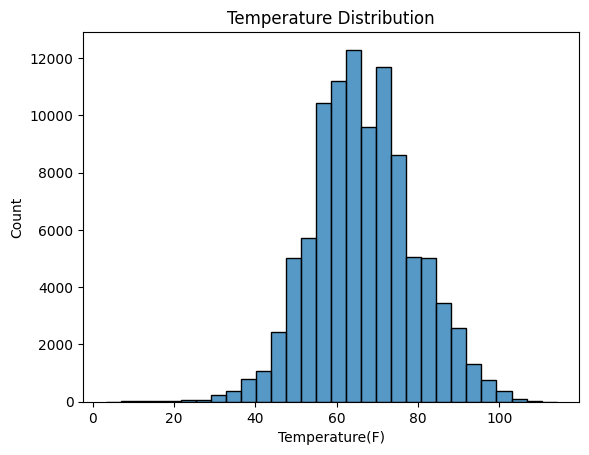

In [ ]:
sns.histplot(df['Temperature(F)'], bins=30)
plt.title("Temperature Distribution")
plt.show()

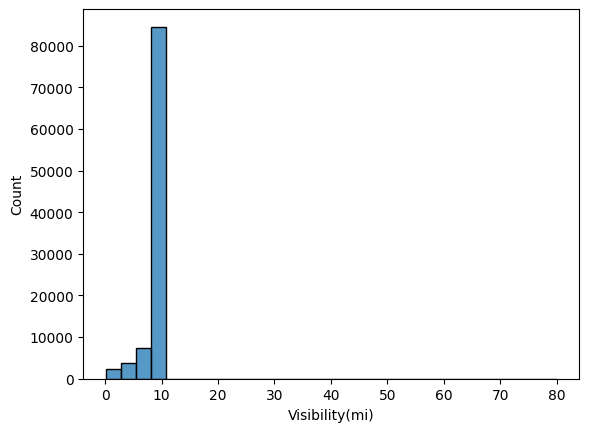

In [ ]:
sns.histplot(df['Visibility(mi)'], bins=30)
plt.show()

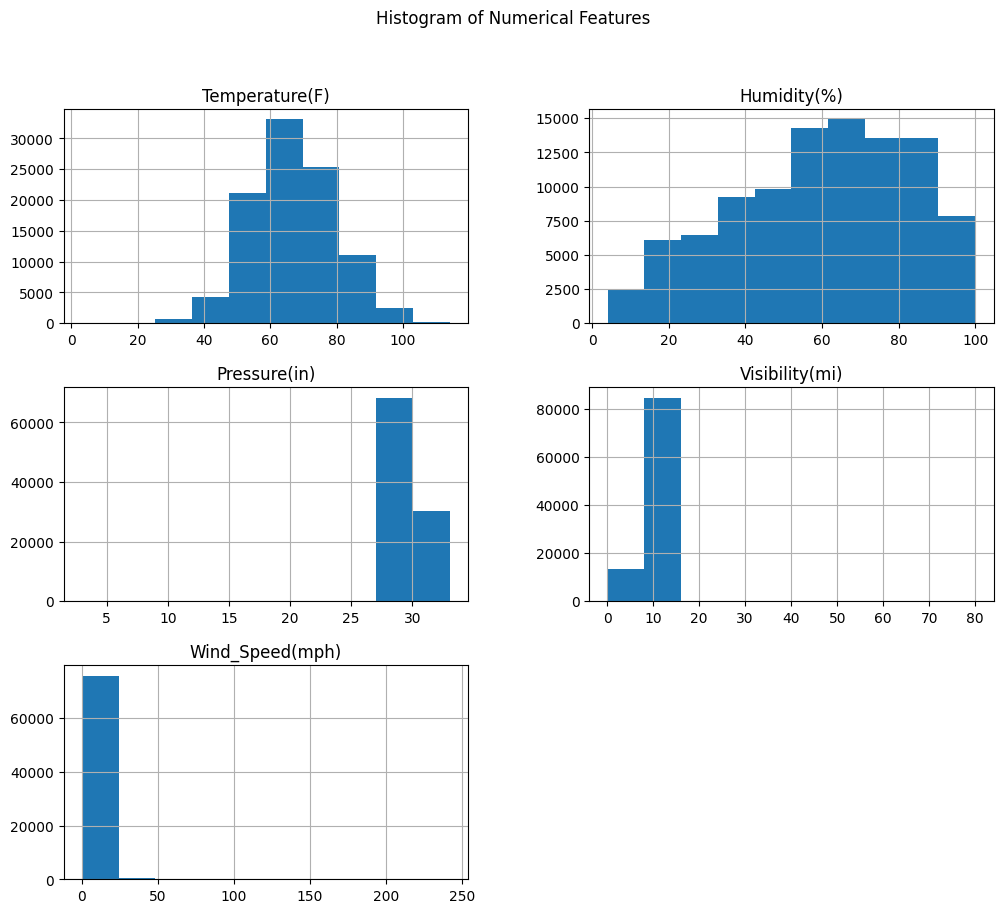

In [ ]:
df[['Temperature(F)','Humidity(%)','Pressure(in)','Visibility(mi)','Wind_Speed(mph)']].hist(figsize=(12,10))
plt.suptitle("Histogram of Numerical Features")
plt.show()

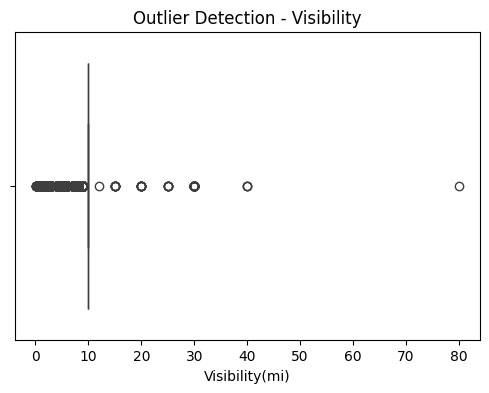

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Visibility(mi)'])
plt.title("Outlier Detection - Visibility")
plt.show()

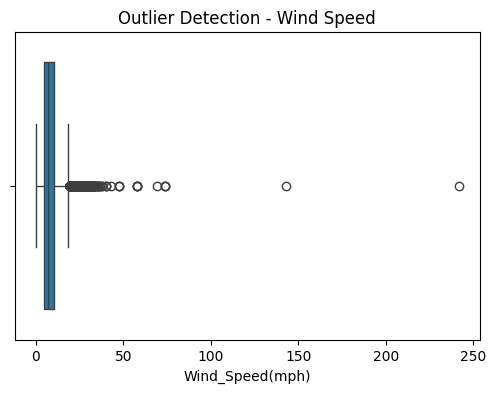

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Wind_Speed(mph)'])
plt.title("Outlier Detection - Wind Speed")
plt.show()

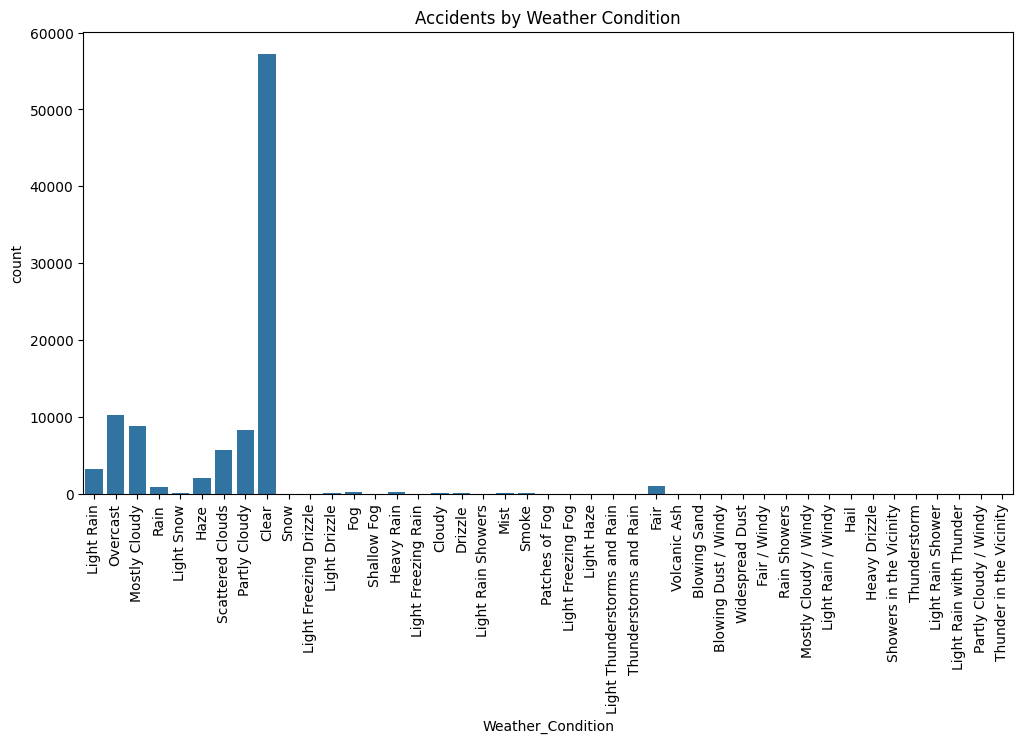

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(x='Weather_Condition', data=df)
plt.xticks(rotation=90)
plt.title("Accidents by Weather Condition")
plt.show()

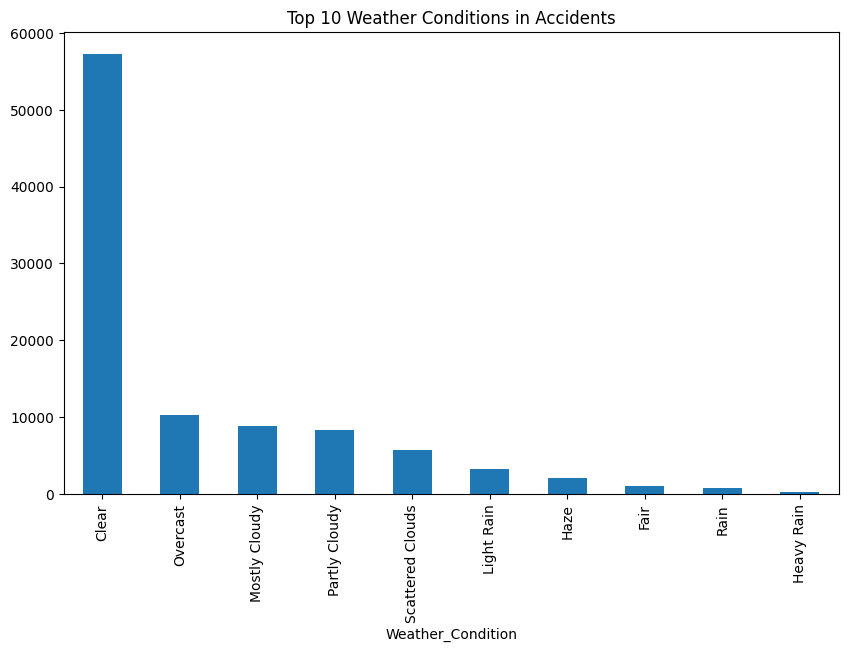

In [ ]:
plt.figure(figsize=(10,6))
df['Weather_Condition'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Weather Conditions in Accidents")
plt.show()

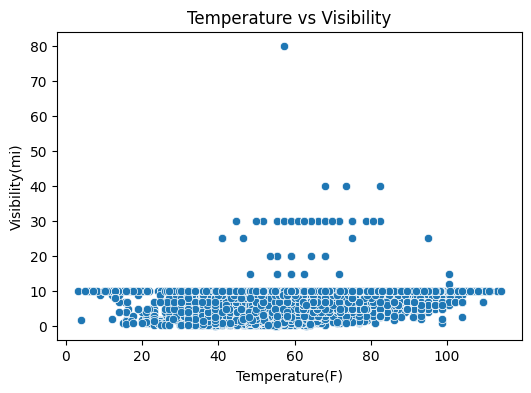

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Temperature(F)', y='Visibility(mi)', data=df)
plt.title("Temperature vs Visibility")
plt.show()

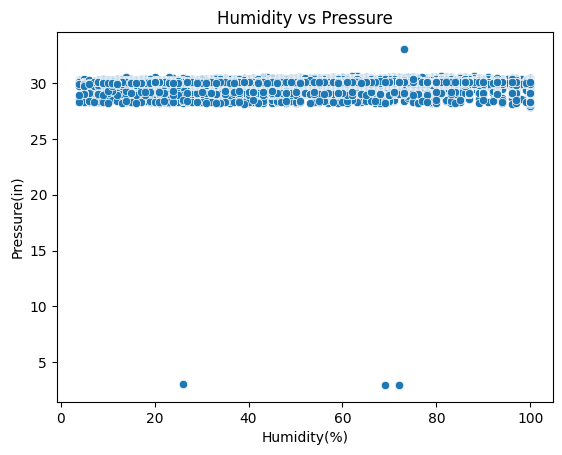

In [ ]:
sns.scatterplot(x='Humidity(%)', y='Pressure(in)', data=df)
plt.title("Humidity vs Pressure")
plt.show()

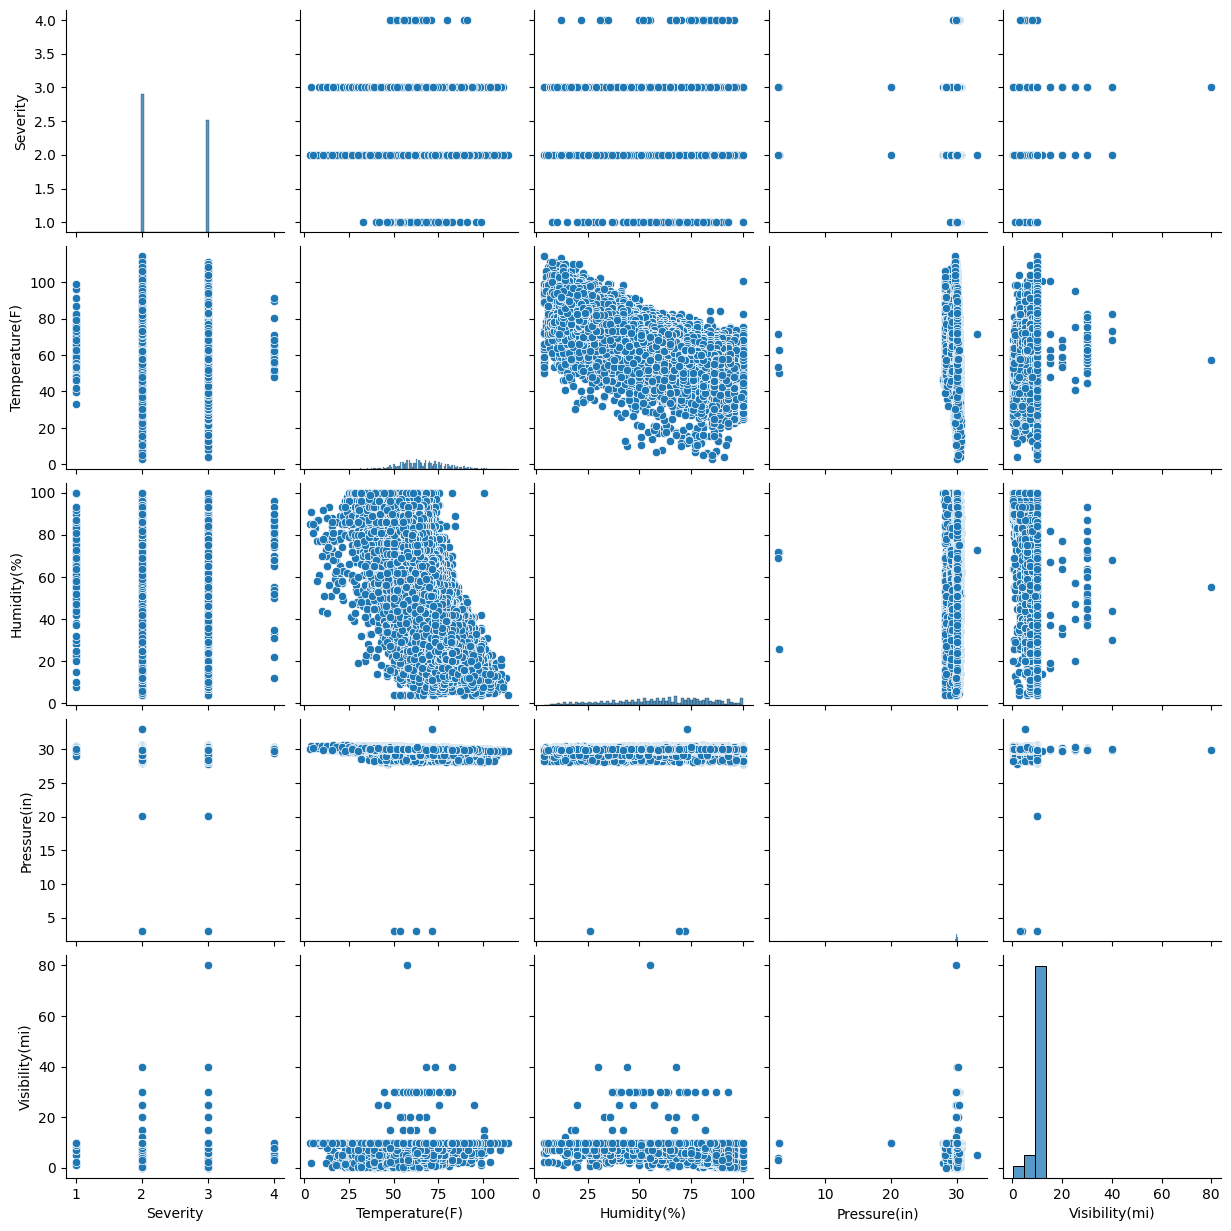

In [ ]:
df_small = df[['Severity','Temperature(F)','Humidity(%)','Pressure(in)','Visibility(mi)']]

sns.pairplot(df_small)
plt.show()

In [ ]:
df = df[['Severity',
         'Temperature(F)',
         'Humidity(%)',
         'Pressure(in)',
         'Visibility(mi)',
         'Wind_Speed(mph)',
         'Weather_Condition',
         'Start_Lat',
         'Start_Lng']]

In [ ]:
df.head()

,Severity,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Weather_Condition,Start_Lat,Start_Lng
0,3,36.9,91.0,29.68,10.0,NaN,Light Rain,39.865147,-84.058723
1,2,37.9,100.0,29.65,10.0,NaN,Light Rain,39.928059,-82.831184
2,2,36.0,100.0,29.67,10.0,3.5,Overcast,39.063148,-84.032608
3,3,35.1,96.0,29.64,9.0,4.6,Mostly Cloudy,39.747753,-84.205582
4,2,36.0,89.0,29.65,6.0,3.5,Mostly Cloudy,39.627781,-84.188354


In [ ]:
df.isnull().sum()

,0
Severity,0
Temperature(F),1591
Humidity(%),1856
Pressure(in),1292
Visibility(mi),1846
Wind_Speed(mph),23820
Weather_Condition,1604
Start_Lat,0
Start_Lng,0


In [ ]:
df.loc[:, 'Temperature(F)'] = df['Temperature(F)'].fillna(df['Temperature(F)'].mean())

df.loc[:, 'Humidity(%)'] = df['Humidity(%)'].fillna(df['Humidity(%)'].mean())

df.loc[:, 'Pressure(in)'] = df['Pressure(in)'].fillna(df['Pressure(in)'].mean())

df.loc[:, 'Visibility(mi)'] = df['Visibility(mi)'].fillna(df['Visibility(mi)'].mean())

df.loc[:, 'Wind_Speed(mph)'] = df['Wind_Speed(mph)'].fillna(df['Wind_Speed(mph)'].mean())

df.loc[:, 'Weather_Condition'] = df['Weather_Condition'].fillna("Unknown")

In [ ]:
df.isnull().sum()

,0
Severity,0
Temperature(F),0
Humidity(%),0
Pressure(in),0
Visibility(mi),0
Wind_Speed(mph),0
Weather_Condition,0
Start_Lat,0
Start_Lng,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df.loc[:, 'Weather_Condition'] = le.fit_transform(df['Weather_Condition'])

In [ ]:
df.head()

,Severity,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Weather_Condition,Start_Lat,Start_Lng
0,3,36.9,91.0,29.68,10.0,8.044165,17,39.865147,-84.058723
1,2,37.9,100.0,29.65,10.0,8.044165,17,39.928059,-82.831184
2,2,36.0,100.0,29.67,10.0,3.500000,27,39.063148,-84.032608
3,3,35.1,96.0,29.64,9.0,4.600000,25,39.747753,-84.205582
4,2,36.0,89.0,29.65,6.0,3.500000,25,39.627781,-84.188354


In [ ]:
X = df.drop('Severity', axis=1)
y = df['Severity']

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df = df[['Severity',
         'Temperature(F)',
         'Humidity(%)',
         'Pressure(in)',
         'Visibility(mi)',
         'Wind_Speed(mph)',
         'Weather_Condition',
         'Start_Lat',
         'Start_Lng']]

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df.loc[:, 'Weather_Condition'] = le.fit_transform(df['Weather_Condition'])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df.drop('Severity', axis=1)
y = df['Severity']

X_scaled = scaler.fit_transform(X)

In [ ]:
import pandas as pd

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Weather_Condition,Start_Lat,Start_Lng
0,-2.354521,1.355309,-1.022151,0.353636,-0.000131,0.395824,2.008538,9.585614
1,-2.275351,1.746191,-1.131259,0.353636,-0.000131,0.395824,2.038439,9.919238
2,-2.425775,1.746191,-1.058520,0.353636,-1.207817,1.192149,1.627361,9.592712
3,-2.497028,1.572466,-1.167628,-0.180918,-0.915474,1.032884,1.952742,9.545701
4,-2.425775,1.268446,-1.131259,-1.784580,-1.207817,1.032884,1.895722,9.550383


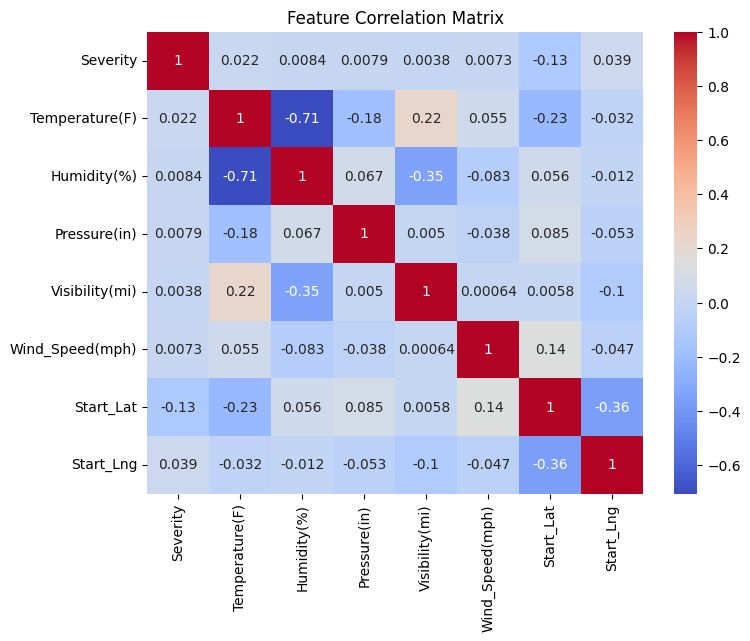

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
print(df.columns)

Index(['Severity', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)',
       'Visibility(mi)', 'Wind_Speed(mph)', 'Weather_Condition', 'Start_Lat',
       'Start_Lng'],
      dtype='object')


In [ ]:
selected_features = ['Temperature(F)',
                     'Humidity(%)',
                     'Pressure(in)',
                     'Visibility(mi)',
                     'Wind_Speed(mph)',
                     'Weather_Condition',
                     'Start_Lat',
                     'Start_Lng']

X = df[selected_features]
y = df['Severity']

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

rfe = RFE(model, n_features_to_select=5)

X_rfe = rfe.fit_transform(X_scaled, y)

print("Selected Features:", X.columns[rfe.support_])

Selected Features: Index(['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Start_Lat',
       'Start_Lng'],
      dtype='object')


In [ ]:
from sklearn.model_selection import train_test_split

# Features and Target
X = df.drop('Severity', axis=1)
y = df['Severity']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (79126, 8)
Testing data size: (19782, 8)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=2000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.5619249823071479


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.8950561116166211


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.848751390152664


In [ ]:
print("Logistic Regression:", acc_lr)
print("Decision Tree:", acc_dt)
print("Random Forest:", acc_rf)

Logistic Regression: 0.5619249823071479
Decision Tree: 0.8950561116166211
Random Forest: 0.848751390152664


In [ ]:
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


RandomForestClassifier(random_state=42)

In [ ]:
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf
}

In [ ]:
# Define class names (OUTSIDE loop)
class_names = ["Mild", "Moderate", "Severe", "Very Severe"]

for idx, (name, model) in enumerate(models.items()):
    ax = axes[idx]

    y_score = model.predict_proba(X_test)

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)

        ax.plot(fpr, tpr, label=f'{class_names[i]} (AUC={roc_auc:.2f})')

    ax.plot([0,1], [0,1], 'k--')
    ax.set_title(name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()

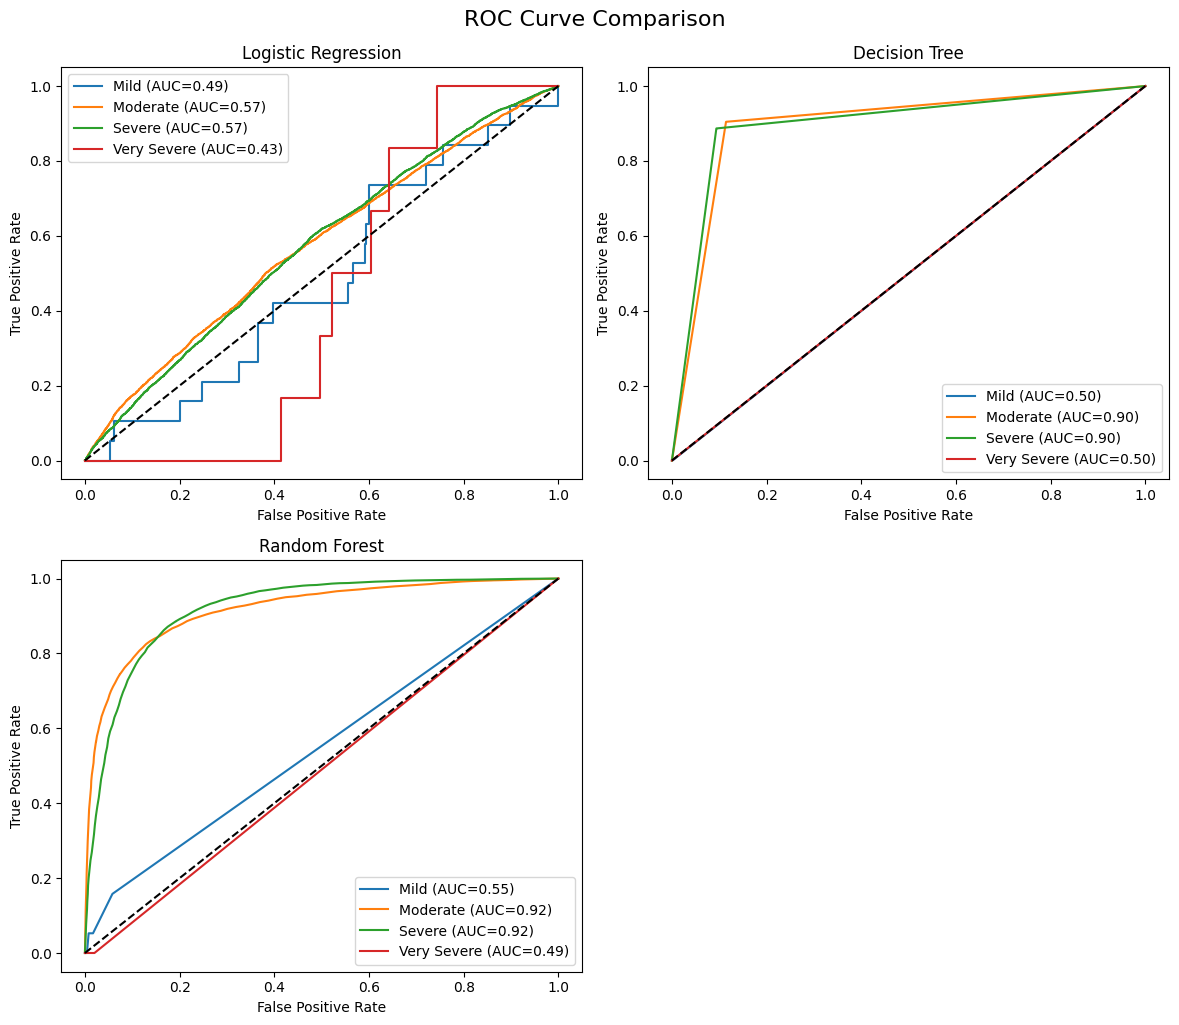

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize target
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Models + predictions
models = {
    "Logistic Regression": lr.predict_proba(X_test),
    "Decision Tree": dt.predict_proba(X_test),
    "Random Forest": rf.predict_proba(X_test)
}

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.ravel()

for idx, (name, y_score) in enumerate(models.items()):
    ax = axes[idx]

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{class_names[i]} (AUC={roc_auc:.2f})')

    ax.plot([0,1], [0,1], 'k--')
    ax.set_title(name)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend()

plt.tight_layout()
fig.delaxes(axes[3])  # removes 4th empty box
plt.suptitle("ROC Curve Comparison", fontsize=16, y=1.02)
plt.show()

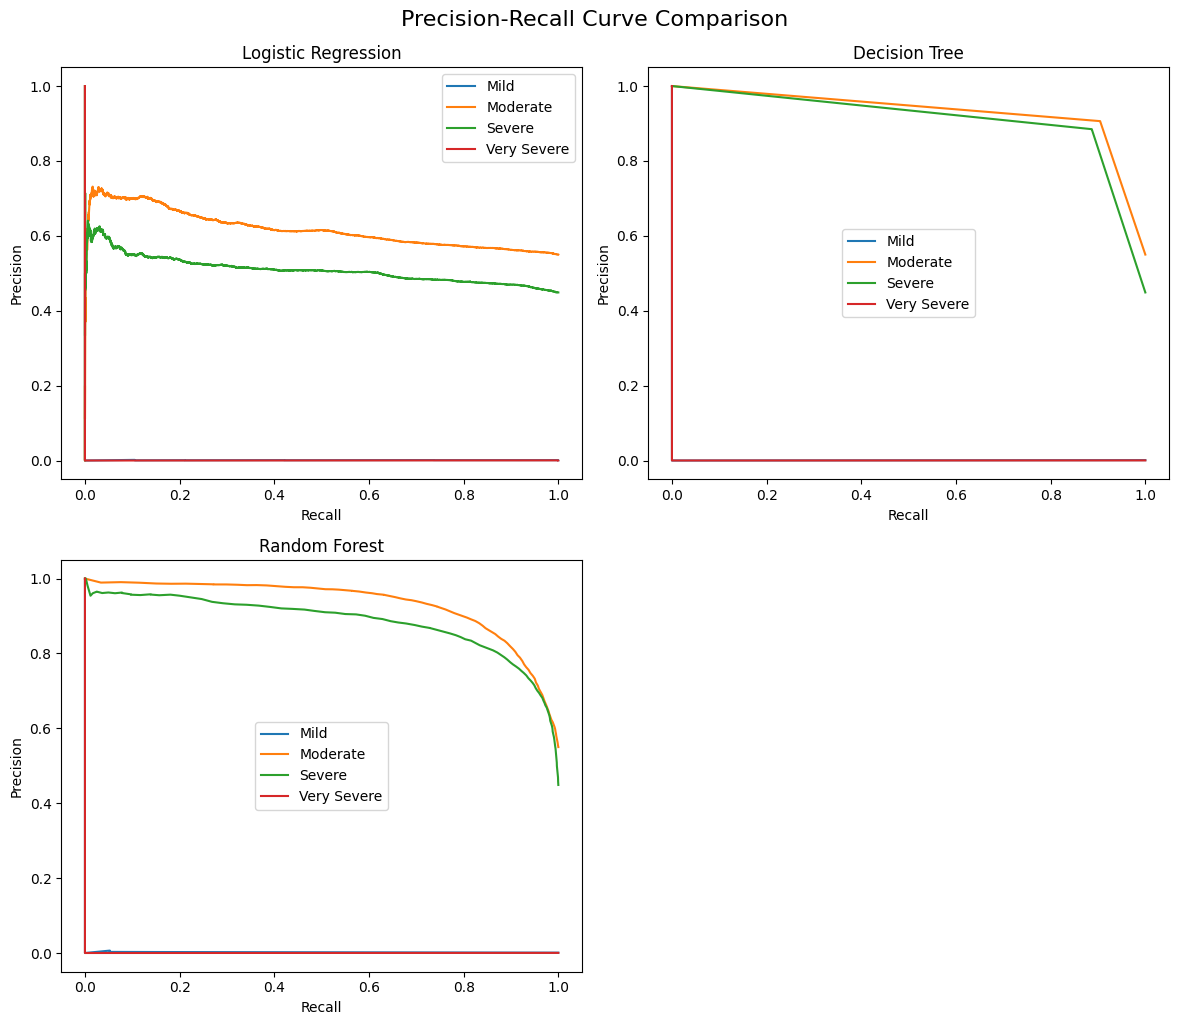

In [ ]:
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(2, 2, figsize=(12,10))
axes = axes.ravel()

for idx, (name, y_score) in enumerate(models.items()):
    ax = axes[idx]

    for i in range(n_classes):
        precision, recall, _ = precision_recall_curve(
            y_test_bin[:, i], y_score[:, i]
        )
        ax.plot(recall, precision,  label=f'{class_names[i]}')

    ax.set_title(name)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()

plt.tight_layout()
fig.delaxes(axes[3])
plt.suptitle("Precision-Recall Curve Comparison", fontsize=16, y=1.02)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


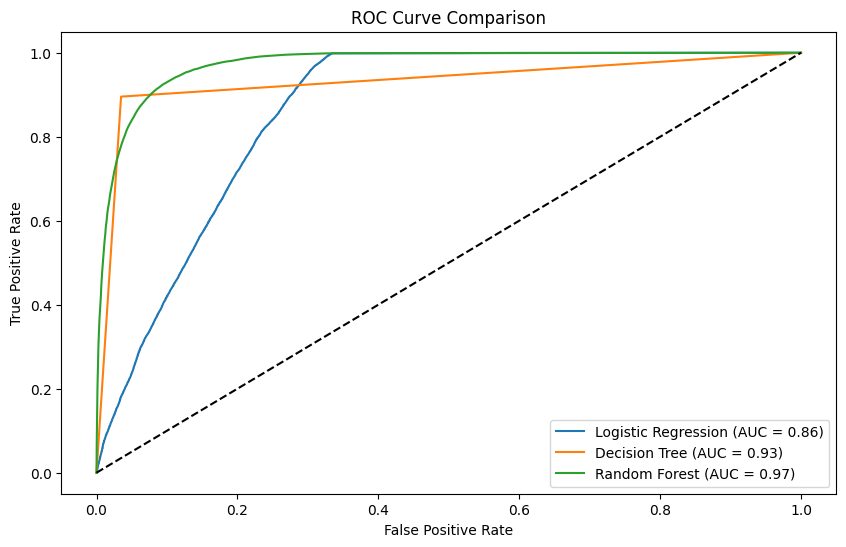

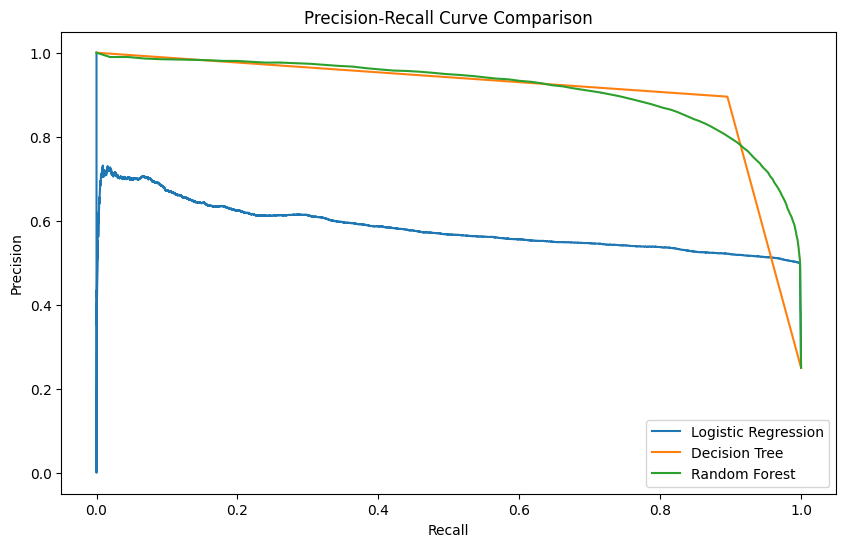

In [ ]:
# =========================
# IMPORT LIBRARIES
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import numpy as np

# =========================
# TRAIN MODELS
# =========================
lr = LogisticRegression(max_iter=2000)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

# =========================
# PREDICT PROBABILITIES
# =========================
y_score_lr = lr.predict_proba(X_test)
y_score_dt = dt.predict_proba(X_test)
y_score_rf = rf.predict_proba(X_test)

# =========================
# BINARIZE TARGET (MULTI-CLASS)
# =========================
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# =========================
# ROC CURVE (ALL MODELS)
# =========================
plt.figure(figsize=(10,6))

for model_name, y_score in zip(
    ["Logistic Regression", "Decision Tree", "Random Forest"],
    [y_score_lr, y_score_dt, y_score_rf]
):
    # Micro-average ROC
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# =========================
# PRECISION-RECALL CURVE (ALL MODELS)
# =========================
plt.figure(figsize=(10,6))

for model_name, y_score in zip(
    ["Logistic Regression", "Decision Tree", "Random Forest"],
    [y_score_lr, y_score_dt, y_score_rf]
):
    precision, recall, _ = precision_recall_curve(
        y_test_bin.ravel(), y_score.ravel()
    )

    plt.plot(recall, precision, label=model_name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

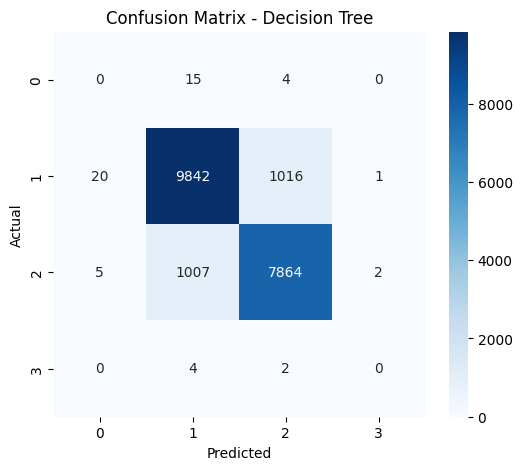

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00        19
           2       0.91      0.90      0.91     10879
           3       0.88      0.89      0.89      8878
           4       0.00      0.00      0.00         6

    accuracy                           0.90     19782
   macro avg       0.45      0.45      0.45     19782
weighted avg       0.90      0.90      0.90     19782



In [ ]:
importance = dt.feature_importances_

import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

             Feature  Importance
7          Start_Lng    0.446304
6          Start_Lat    0.425771
2       Pressure(in)    0.034662
0     Temperature(F)    0.030286
1        Humidity(%)    0.029835
4    Wind_Speed(mph)    0.018353
5  Weather_Condition    0.008610
3     Visibility(mi)    0.006180


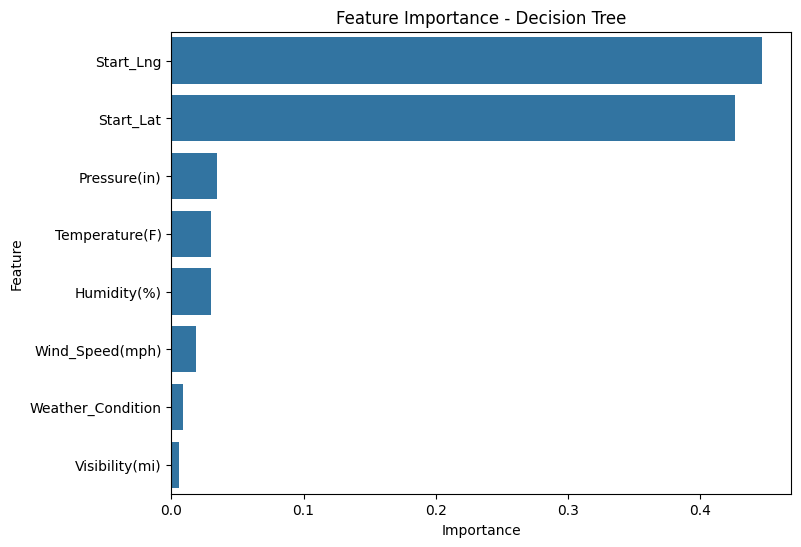

In [ ]:
plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)

plt.title("Feature Importance - Decision Tree")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       param_grid,
                       cv=3)

grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [ ]:
best_dt = grid_dt.best_estimator_

y_pred_best = best_dt.predict(X_test)

from sklearn.metrics import accuracy_score
print("Tuned Decision Tree Accuracy:", accuracy_score(y_test, y_pred_best))

Tuned Decision Tree Accuracy: 0.9083004751794561
